In [1]:
import os
import glob
import pandas as pd

base_path = "/Users/vihangainduwara/Desktop/MelanoDetect/data/ham10000"
metadata_path = os.path.join(base_path, "HAM10000_metadata.csv")
images_part1 = os.path.join(base_path, "HAM10000_images_part_1")
images_part2 = os.path.join(base_path, "HAM10000_images_part_2")

df = pd.read_csv(metadata_path)

image_paths_part1 = glob.glob(os.path.join(images_part1, "*.jpg"))
image_paths_part2 = glob.glob(os.path.join(images_part2, "*.jpg"))
all_image_paths = image_paths_part1 + image_paths_part2

image_path_dict = {
    os.path.splitext(os.path.basename(path))[0]: path
    for path in all_image_paths
}

df["image_path"] = df["image_id"].map(image_path_dict)

print(df.shape)
print("Missing image paths:", df["image_path"].isna().sum())
df.head()

(10015, 8)
Missing image paths: 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/Users/vihangainduwara/Desktop/MelanoDetect/da...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/Users/vihangainduwara/Desktop/MelanoDetect/da...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/Users/vihangainduwara/Desktop/MelanoDetect/da...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/Users/vihangainduwara/Desktop/MelanoDetect/da...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/Users/vihangainduwara/Desktop/MelanoDetect/da...


In [2]:
binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)
print(df["binary_label"].value_counts())

binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

binary_train_df, binary_temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["binary_label"],
    random_state=42
)

binary_val_df, binary_test_df = train_test_split(
    binary_temp_df,
    test_size=0.50,
    stratify=binary_temp_df["binary_label"],
    random_state=42
)

binary_train_df = binary_train_df.reset_index(drop=True)
binary_val_df = binary_val_df.reset_index(drop=True)
binary_test_df = binary_test_df.reset_index(drop=True)

print("Train shape:", binary_train_df.shape)
print("Validation shape:", binary_val_df.shape)
print("Test shape:", binary_test_df.shape)

Train shape: (7010, 9)
Validation shape: (1502, 9)
Test shape: (1503, 9)


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

EFF_IMG_SIZE = (224, 224)
EFF_BATCH_SIZE = 16

In [5]:
eff_train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

eff_val_test_datagen = ImageDataGenerator()

In [6]:
eff_train_generator = eff_train_datagen.flow_from_dataframe(
    dataframe=binary_train_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=EFF_IMG_SIZE,
    batch_size=EFF_BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

Found 7010 validated image filenames belonging to 2 classes.


In [7]:
eff_val_generator = eff_val_test_datagen.flow_from_dataframe(
    dataframe=binary_val_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=EFF_IMG_SIZE,
    batch_size=EFF_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1502 validated image filenames belonging to 2 classes.


In [8]:
eff_test_generator = eff_val_test_datagen.flow_from_dataframe(
    dataframe=binary_test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=EFF_IMG_SIZE,
    batch_size=EFF_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1503 validated image filenames belonging to 2 classes.


In [9]:
print(eff_train_generator.class_indices)

eff_images, eff_labels = next(eff_train_generator)
print("EfficientNet image batch shape:", eff_images.shape)
print("EfficientNet label batch shape:", eff_labels.shape)
print("Image min/max:", eff_images.min(), eff_images.max())

{'benign': 0, 'malignant': 1}
EfficientNet image batch shape: (16, 224, 224, 3)
EfficientNet label batch shape: (16,)
Image min/max: 0.0 250.9198


In [10]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

In [11]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False
print("Base model loaded and frozen")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 23s 1us/step
Base model loaded and frozen


In [12]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

eff_model = tf.keras.Model(inputs, outputs)
print("EfficientNetB0 model created")

EfficientNetB0 model created


In [13]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("EfficientNetB0 model compiled")

EfficientNetB0 model compiled


In [14]:
eff_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
eff_checkpoint_path = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary.keras"
print(eff_checkpoint_path)

/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary.keras


In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

eff_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=eff_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks ready")

Callbacks ready


In [17]:
eff_history = eff_model.fit(
    eff_train_generator,
    validation_data=eff_val_generator,
    epochs=10,
    callbacks=eff_callbacks
)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7982 - loss: 0.4402
Epoch 1: val_loss improved from None to 0.37427, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 88s 194ms/step - accuracy: 0.8087 - loss: 0.4073 - val_accuracy: 0.8209 - val_loss: 0.3743 - learning_rate: 0.0010
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8204 - loss: 0.3757
Epoch 2: val_loss improved from 0.37427 to 0.36509, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 86s 196ms/step - accuracy: 0.8264 - loss: 0.3653 - val_accuracy: 0.8256 - val_loss: 0.3651 - learning_rate: 0.0010
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.8351 - loss: 0.3444
Epoch 3: val_loss improved from 0.36509 to 0.35720, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientne

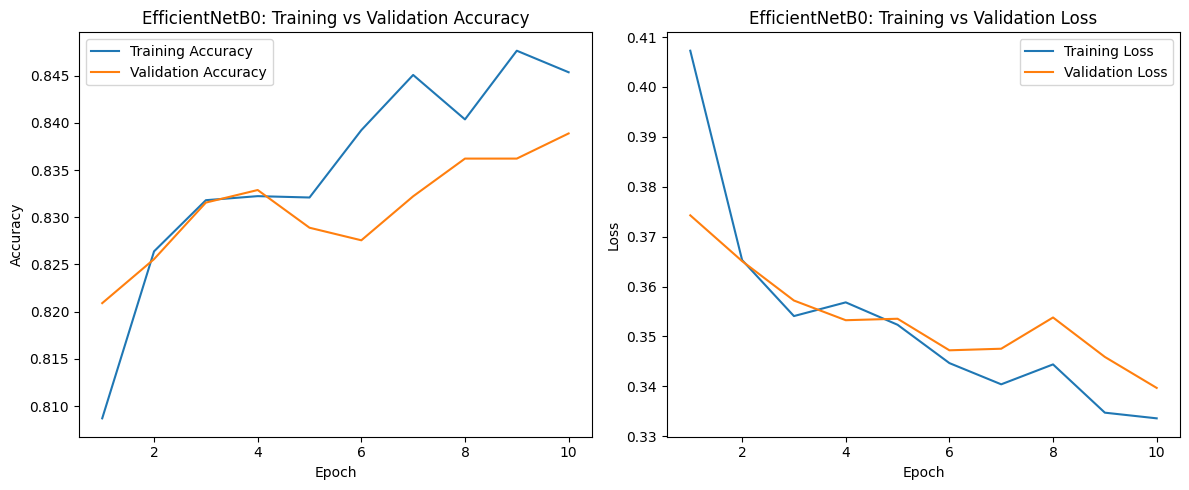

In [18]:
import matplotlib.pyplot as plt

acc = eff_history.history["accuracy"]
val_acc = eff_history.history["val_accuracy"]
loss = eff_history.history["loss"]
val_loss = eff_history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("EfficientNetB0: Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("EfficientNetB0: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [19]:
import tensorflow as tf

best_eff_model = tf.keras.models.load_model(eff_checkpoint_path)
print("Best EfficientNetB0 model loaded successfully")

Best EfficientNetB0 model loaded successfully


In [20]:
eff_test_loss, eff_test_acc = best_eff_model.evaluate(eff_test_generator)
print("EfficientNetB0 Test Loss:", eff_test_loss)
print("EfficientNetB0 Test Accuracy:", eff_test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 145ms/step - accuracy: 0.8377 - loss: 0.3366
EfficientNetB0 Test Loss: 0.33660954236984253
EfficientNetB0 Test Accuracy: 0.8376579880714417


In [21]:
import numpy as np

eff_test_generator.reset()
eff_pred_probs = best_eff_model.predict(eff_test_generator, verbose=1).flatten()
eff_true_labels = eff_test_generator.classes

print("Total predictions:", len(eff_pred_probs))
print("Total true labels:", len(eff_true_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step
Total predictions: 1503
Total true labels: 1503


Classification Report at threshold = 0.5

              precision    recall  f1-score   support

      benign       0.86      0.95      0.90      1210
   malignant       0.65      0.37      0.47       293

    accuracy                           0.84      1503
   macro avg       0.75      0.66      0.69      1503
weighted avg       0.82      0.84      0.82      1503



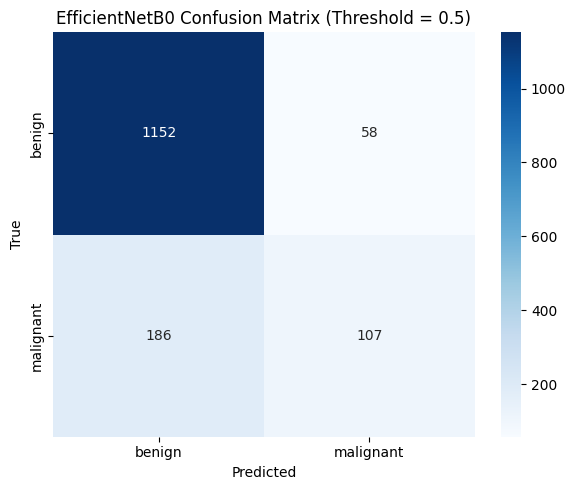

In [22]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

eff_pred_labels_05 = (eff_pred_probs > 0.5).astype(int)

print("Classification Report at threshold = 0.5\n")
print(classification_report(
    eff_true_labels,
    eff_pred_labels_05,
    target_names=["benign", "malignant"]
))

cm_05 = confusion_matrix(eff_true_labels, eff_pred_labels_05)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_05,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["benign", "malignant"],
    yticklabels=["benign", "malignant"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("EfficientNetB0 Confusion Matrix (Threshold = 0.5)")
plt.tight_layout()
plt.show()

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]
results = []

for t in thresholds:
    preds = (eff_pred_probs > t).astype(int)

    acc = accuracy_score(eff_true_labels, preds)
    precision = precision_score(eff_true_labels, preds)
    recall = recall_score(eff_true_labels, preds)
    f1 = f1_score(eff_true_labels, preds)

    results.append({
        "threshold": t,
        "accuracy": acc,
        "precision_malignant": precision,
        "recall_malignant": recall,
        "f1_malignant": f1
    })

eff_threshold_results_df = pd.DataFrame(results)
eff_threshold_results_df.round(3)

,threshold,accuracy,precision_malignant,recall_malignant,f1_malignant
0,0.50,0.838,0.648,0.365,0.467
1,0.45,0.838,0.621,0.430,0.508
2,0.40,0.836,0.591,0.509,0.547
3,0.35,0.836,0.577,0.590,0.583
4,0.30,0.824,0.540,0.672,0.599


In [24]:
base_model.trainable = True

# Freeze the lower layers, unfreeze only the top part
for layer in base_model.layers[:-20]:
    layer.trainable = False

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tune_history = eff_model.fit(
    eff_train_generator,
    validation_data=eff_val_generator,
    epochs=10,
    callbacks=eff_callbacks
)

Epoch 1/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.6682 - loss: 0.6738
Epoch 1: val_loss did not improve from 0.33969
439/439 ━━━━━━━━━━━━━━━━━━━━ 104s 231ms/step - accuracy: 0.7424 - loss: 0.5337 - val_accuracy: 0.8103 - val_loss: 0.4101 - learning_rate: 1.0000e-05
Epoch 2/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8171 - loss: 0.3945
Epoch 2: val_loss did not improve from 0.33969

Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
439/439 ━━━━━━━━━━━━━━━━━━━━ 93s 212ms/step - accuracy: 0.8251 - loss: 0.3855 - val_accuracy: 0.8156 - val_loss: 0.3905 - learning_rate: 1.0000e-05
Epoch 3/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.8236 - loss: 0.3796
Epoch 3: val_loss did not improve from 0.33969
439/439 ━━━━━━━━━━━━━━━━━━━━ 90s 204ms/step - accuracy: 0.8344 - loss: 0.3655 - val_accuracy: 0.8189 - val_loss: 0.3804 - learning_rate: 5.0000e-06
Epoch 4/10
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.8283 

In [30]:
import tensorflow as tf

eff_checkpoint_path = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary.keras"
best_eff_model = tf.keras.models.load_model(eff_checkpoint_path)

print("Best EfficientNetB0 model loaded successfully")

Best EfficientNetB0 model loaded successfully


In [31]:
eff_test_loss, eff_test_acc = best_eff_model.evaluate(eff_test_generator)
print("EfficientNetB0 Test Loss:", eff_test_loss)
print("EfficientNetB0 Test Accuracy:", eff_test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.8377 - loss: 0.3366
EfficientNetB0 Test Loss: 0.33660954236984253
EfficientNetB0 Test Accuracy: 0.8376579880714417


In [32]:
import numpy as np

eff_test_generator.reset()
eff_pred_probs = best_eff_model.predict(eff_test_generator, verbose=1).flatten()
eff_true_labels = eff_test_generator.classes

print("Total predictions:", len(eff_pred_probs))
print("Total true labels:", len(eff_true_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 153ms/step
Total predictions: 1503
Total true labels: 1503


Classification Report at threshold = 0.35

              precision    recall  f1-score   support

      benign       0.90      0.90      0.90      1210
   malignant       0.58      0.59      0.58       293

    accuracy                           0.84      1503
   macro avg       0.74      0.74      0.74      1503
weighted avg       0.84      0.84      0.84      1503



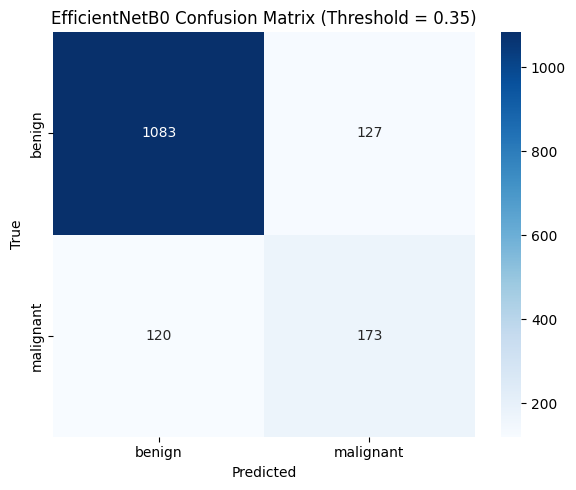

In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

chosen_threshold = 0.35
eff_pred_labels_best = (eff_pred_probs > chosen_threshold).astype(int)

print(f"Classification Report at threshold = {chosen_threshold}\n")
print(classification_report(
    eff_true_labels,
    eff_pred_labels_best,
    target_names=["benign", "malignant"]
))

eff_cm = confusion_matrix(eff_true_labels, eff_pred_labels_best)

plt.figure(figsize=(6,5))
sns.heatmap(
    eff_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["benign", "malignant"],
    yticklabels=["benign", "malignant"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"EfficientNetB0 Confusion Matrix (Threshold = {chosen_threshold})")
plt.tight_layout()
plt.show()

In [34]:
import tensorflow as tf

best_eff_path = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary.keras"
ft_model = tf.keras.models.load_model(best_eff_path)

print("Best EfficientNetB0 model loaded for careful fine-tuning")

Best EfficientNetB0 model loaded for careful fine-tuning


In [35]:
for i, layer in enumerate(ft_model.layers):
    print(i, layer.name, "-", layer.__class__.__name__)

0 input_layer_1 - InputLayer
1 efficientnetb0 - Functional
2 global_average_pooling2d - GlobalAveragePooling2D
3 dropout - Dropout
4 dense - Dense


In [36]:
base_model_ft = ft_model.get_layer("efficientnetb0")
print("Base model name:", base_model_ft.name)
print("Total layers in base model:", len(base_model_ft.layers))

Base model name: efficientnetb0
Total layers in base model: 238


In [37]:
base_model_ft.trainable = True

for layer in base_model_ft.layers:
    layer.trainable = False

print("All EfficientNet base layers frozen first")

All EfficientNet base layers frozen first


In [38]:
from tensorflow.keras.layers import BatchNormalization

for layer in base_model_ft.layers[-15:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

print("Top 15 layers unfrozen, BatchNormalization layers kept frozen")

Top 15 layers unfrozen, BatchNormalization layers kept frozen


In [39]:
for layer in base_model_ft.layers[-20:]:
    print(layer.name, "-", layer.trainable)

block6d_project_conv - False
block6d_project_bn - False
block6d_drop - False
block6d_add - False
block7a_expand_conv - False
block7a_expand_bn - False
block7a_expand_activation - True
block7a_dwconv - True
block7a_bn - False
block7a_activation - True
block7a_se_squeeze - True
block7a_se_reshape - True
block7a_se_reduce - True
block7a_se_expand - True
block7a_se_excite - True
block7a_project_conv - True
block7a_project_bn - False
top_conv - True
top_bn - False
top_activation - True


In [40]:
ft_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Careful fine-tuning model compiled")

Careful fine-tuning model compiled


In [41]:
ft_checkpoint_path = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft15.keras"
print(ft_checkpoint_path)

/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft15.keras


In [42]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

ft_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=ft_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

print("Fine-tuning callbacks ready")

Fine-tuning callbacks ready


In [43]:
ft_history = ft_model.fit(
    eff_train_generator,
    validation_data=eff_val_generator,
    epochs=5,
    callbacks=ft_callbacks
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8463 - loss: 0.3319
Epoch 1: val_loss improved from None to 0.33903, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft15.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 84s 184ms/step - accuracy: 0.8445 - loss: 0.3322 - val_accuracy: 0.8375 - val_loss: 0.3390 - learning_rate: 1.0000e-05
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.8463 - loss: 0.3196
Epoch 2: val_loss improved from 0.33903 to 0.33572, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft15.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 76s 174ms/step - accuracy: 0.8432 - loss: 0.3263 - val_accuracy: 0.8409 - val_loss: 0.3357 - learning_rate: 1.0000e-05
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8437 - loss: 0.3264
Epoch 3: val_loss did not improve from 0.33572

Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.


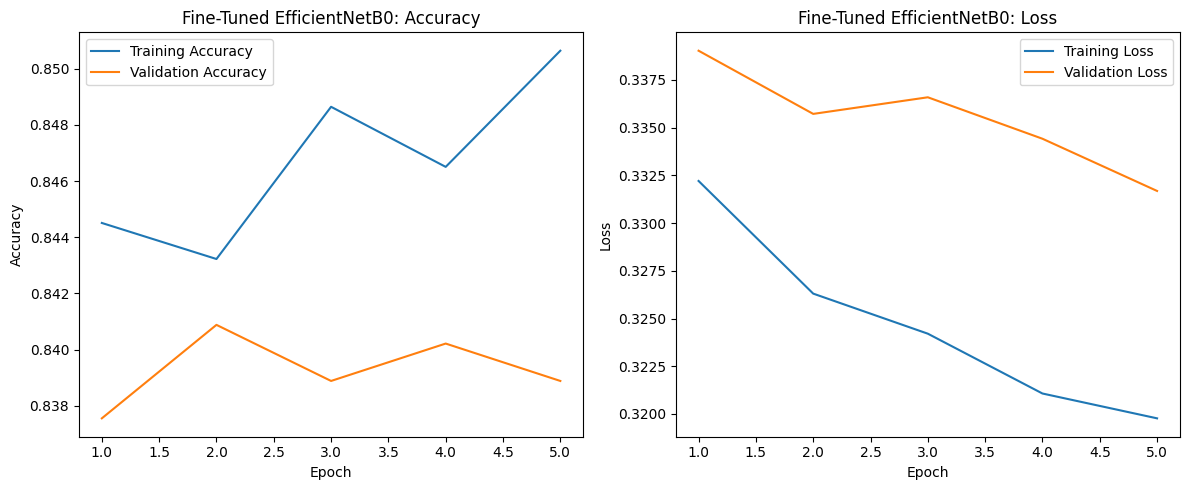

In [44]:
import matplotlib.pyplot as plt

acc = ft_history.history["accuracy"]
val_acc = ft_history.history["val_accuracy"]
loss = ft_history.history["loss"]
val_loss = ft_history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.title("Fine-Tuned EfficientNetB0: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Fine-Tuned EfficientNetB0: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [45]:
import tensorflow as tf

best_ft_model = tf.keras.models.load_model(ft_checkpoint_path)
print("Best fine-tuned model loaded successfully")

Best fine-tuned model loaded successfully


In [46]:
ft_test_loss, ft_test_acc = best_ft_model.evaluate(eff_test_generator)
print("Fine-Tuned EfficientNetB0 Test Loss:", ft_test_loss)
print("Fine-Tuned EfficientNetB0 Test Accuracy:", ft_test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 175ms/step - accuracy: 0.8423 - loss: 0.3245
Fine-Tuned EfficientNetB0 Test Loss: 0.3244534432888031
Fine-Tuned EfficientNetB0 Test Accuracy: 0.8423153758049011


In [47]:
import numpy as np

eff_test_generator.reset()
ft_pred_probs = best_ft_model.predict(eff_test_generator, verbose=1).flatten()
ft_true_labels = eff_test_generator.classes

print("Total predictions:", len(ft_pred_probs))
print("Total true labels:", len(ft_true_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 149ms/step
Total predictions: 1503
Total true labels: 1503


In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]
results = []

for t in thresholds:
    preds = (ft_pred_probs > t).astype(int)

    acc = accuracy_score(ft_true_labels, preds)
    precision = precision_score(ft_true_labels, preds)
    recall = recall_score(ft_true_labels, preds)
    f1 = f1_score(ft_true_labels, preds)

    results.append({
        "threshold": t,
        "accuracy": acc,
        "precision_malignant": precision,
        "recall_malignant": recall,
        "f1_malignant": f1
    })

ft_threshold_results_df = pd.DataFrame(results)
ft_threshold_results_df.round(3)

,threshold,accuracy,precision_malignant,recall_malignant,f1_malignant
0,0.50,0.842,0.652,0.410,0.503
1,0.45,0.843,0.626,0.485,0.546
2,0.40,0.840,0.598,0.553,0.574
3,0.35,0.834,0.568,0.625,0.595
4,0.30,0.830,0.549,0.706,0.618


In [49]:
import tensorflow as tf

best_ft_path = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft15.keras"
ft_model_v2 = tf.keras.models.load_model(best_ft_path)

print("Best fine-tuned model loaded successfully")

Best fine-tuned model loaded successfully


In [50]:
base_model_ft_v2 = ft_model_v2.get_layer("efficientnetb0")
print("Base model name:", base_model_ft_v2.name)
print("Total layers in base model:", len(base_model_ft_v2.layers))

Base model name: efficientnetb0
Total layers in base model: 238


In [51]:
base_model_ft_v2.trainable = True

for layer in base_model_ft_v2.layers:
    layer.trainable = False

print("All base layers frozen")

All base layers frozen


In [52]:
from tensorflow.keras.layers import BatchNormalization

for layer in base_model_ft_v2.layers[-10:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

print("Top 10 layers unfrozen, BatchNormalization layers kept frozen")

Top 10 layers unfrozen, BatchNormalization layers kept frozen


In [53]:
ft_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled with lower learning rate")

Model compiled with lower learning rate


In [54]:
ft_checkpoint_path_v2 = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras"
print(ft_checkpoint_path_v2)

/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras


In [55]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

ft_callbacks_v2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=ft_checkpoint_path_v2,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks ready")

Callbacks ready


In [56]:
ft_history_v2 = ft_model_v2.fit(
    eff_train_generator,
    validation_data=eff_val_generator,
    epochs=5,
    callbacks=ft_callbacks_v2
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8554 - loss: 0.3243
Epoch 1: val_loss improved from None to 0.33194, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 85s 187ms/step - accuracy: 0.8558 - loss: 0.3154 - val_accuracy: 0.8415 - val_loss: 0.3319 - learning_rate: 5.0000e-06
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8526 - loss: 0.3160
Epoch 2: val_loss improved from 0.33194 to 0.33187, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras

Epoch 2: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
439/439 ━━━━━━━━━━━━━━━━━━━━ 84s 192ms/step - accuracy: 0.8512 - loss: 0.3215 - val_accuracy: 0.8409 - val_loss: 0.3319 - learning_rate: 5.0000e-06
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8483 - loss: 0.3228
Epoch 3: val_loss improved from 0.33187 to 0.32

In [57]:
import tensorflow as tf

best_ft10_model = tf.keras.models.load_model(ft_checkpoint_path_v2)
print("Best ft10 model loaded successfully")

Best ft10 model loaded successfully


In [58]:
ft10_test_loss, ft10_test_acc = best_ft10_model.evaluate(eff_test_generator)
print("FT10 Test Loss:", ft10_test_loss)
print("FT10 Test Accuracy:", ft10_test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.8450 - loss: 0.3229
FT10 Test Loss: 0.32292440533638
FT10 Test Accuracy: 0.8449767231941223


In [59]:
import numpy as np

eff_test_generator.reset()
ft10_pred_probs = best_ft10_model.predict(eff_test_generator, verbose=1).flatten()
ft10_true_labels = eff_test_generator.classes

print("Total predictions:", len(ft10_pred_probs))
print("Total true labels:", len(ft10_true_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step
Total predictions: 1503
Total true labels: 1503


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]
results = []

for t in thresholds:
    preds = (ft10_pred_probs > t).astype(int)

    acc = accuracy_score(ft10_true_labels, preds)
    precision = precision_score(ft10_true_labels, preds)
    recall = recall_score(ft10_true_labels, preds)
    f1 = f1_score(ft10_true_labels, preds)

    results.append({
        "threshold": t,
        "accuracy": acc,
        "precision_malignant": precision,
        "recall_malignant": recall,
        "f1_malignant": f1
    })

ft10_threshold_results_df = pd.DataFrame(results)
ft10_threshold_results_df.round(3)

,threshold,accuracy,precision_malignant,recall_malignant,f1_malignant
0,0.50,0.845,0.663,0.416,0.512
1,0.45,0.846,0.636,0.488,0.552
2,0.40,0.844,0.608,0.556,0.581
3,0.35,0.836,0.573,0.618,0.594
4,0.30,0.832,0.554,0.703,0.620


In [61]:
import os

model_files = [
    "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_binary_cnn_v2.keras",
    "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary.keras",
    "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft15.keras",
    "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras"
]

for path in model_files:
    print(path, "->", os.path.exists(path))

/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_binary_cnn_v2.keras -> True
/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary.keras -> True
/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft15.keras -> True
/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras -> True


In [62]:
print("Best current model: ham10000_efficientnetb0_binary_ft10.keras")
print("Best test accuracy: 0.845")
print("Recommended threshold: 0.35")

Best current model: ham10000_efficientnetb0_binary_ft10.keras
Best test accuracy: 0.845
Recommended threshold: 0.35


In [2]:
import os
import glob
import pandas as pd

base_path = "/Users/vihangainduwara/Desktop/MelanoDetect/data/ham10000"
metadata_path = os.path.join(base_path, "HAM10000_metadata.csv")
images_part1 = os.path.join(base_path, "HAM10000_images_part_1")
images_part2 = os.path.join(base_path, "HAM10000_images_part_2")

df = pd.read_csv(metadata_path)

image_paths_part1 = glob.glob(os.path.join(images_part1, "*.jpg"))
image_paths_part2 = glob.glob(os.path.join(images_part2, "*.jpg"))
all_image_paths = image_paths_part1 + image_paths_part2

image_path_dict = {
    os.path.splitext(os.path.basename(path))[0]: path
    for path in all_image_paths
}

df["image_path"] = df["image_id"].map(image_path_dict)

print(df.shape)
print("Missing image paths:", df["image_path"].isna().sum())

(10015, 8)
Missing image paths: 0


In [4]:
binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)
print(df["binary_label"].value_counts())

binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

binary_train_df, binary_temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["binary_label"],
    random_state=42
)

binary_val_df, binary_test_df = train_test_split(
    binary_temp_df,
    test_size=0.50,
    stratify=binary_temp_df["binary_label"],
    random_state=42
)

binary_train_df = binary_train_df.reset_index(drop=True)
binary_val_df = binary_val_df.reset_index(drop=True)
binary_test_df = binary_test_df.reset_index(drop=True)

print("Train shape:", binary_train_df.shape)
print("Validation shape:", binary_val_df.shape)
print("Test shape:", binary_test_df.shape)

Train shape: (7010, 9)
Validation shape: (1502, 9)
Test shape: (1503, 9)


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

FOCAL_IMG_SIZE = (224, 224)
FOCAL_BATCH_SIZE = 16

focal_train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True
)

focal_val_test_datagen = ImageDataGenerator()

In [7]:
focal_train_generator = focal_train_datagen.flow_from_dataframe(
    dataframe=binary_train_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=FOCAL_IMG_SIZE,
    batch_size=FOCAL_BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

Found 7010 validated image filenames belonging to 2 classes.


In [8]:
focal_val_generator = focal_val_test_datagen.flow_from_dataframe(
    dataframe=binary_val_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=FOCAL_IMG_SIZE,
    batch_size=FOCAL_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1502 validated image filenames belonging to 2 classes.


In [9]:
focal_test_generator = focal_val_test_datagen.flow_from_dataframe(
    dataframe=binary_test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=FOCAL_IMG_SIZE,
    batch_size=FOCAL_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1503 validated image filenames belonging to 2 classes.


In [10]:
print(focal_train_generator.class_indices)

focal_images, focal_labels = next(focal_train_generator)
print("Image batch shape:", focal_images.shape)
print("Label batch shape:", focal_labels.shape)
print("Image min/max:", focal_images.min(), focal_images.max())

{'benign': 0, 'malignant': 1}
Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)
Image min/max: 0.0 255.0


In [12]:
import tensorflow as tf

best_ft10_path = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras"
focal_model = tf.keras.models.load_model(best_ft10_path)

print("Best ft10 model loaded successfully")

Best ft10 model loaded successfully


In [13]:
import tensorflow as tf

def binary_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow(1.0 - p_t, gamma)

        loss = alpha_factor * modulating_factor * bce
        return tf.reduce_mean(loss)

    return loss_fn

In [14]:
focal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=binary_focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"]
)

print("Model compiled with focal loss")

Model compiled with focal loss


In [15]:
focal_checkpoint_path = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_focal.keras"
print(focal_checkpoint_path)

/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_focal.keras


In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

focal_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=focal_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

print("Focal loss callbacks ready")

Focal loss callbacks ready


In [17]:
focal_history = focal_model.fit(
    focal_train_generator,
    validation_data=focal_val_generator,
    epochs=5,
    callbacks=focal_callbacks
)

Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.8588 - loss: 0.0426
Epoch 1: val_loss improved from None to 0.04047, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_focal.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 104s 229ms/step - accuracy: 0.8514 - loss: 0.0412 - val_accuracy: 0.8442 - val_loss: 0.0405 - learning_rate: 5.0000e-06
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8433 - loss: 0.0392
Epoch 2: val_loss improved from 0.04047 to 0.03661, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_focal.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 87s 199ms/step - accuracy: 0.8439 - loss: 0.0384 - val_accuracy: 0.8462 - val_loss: 0.0366 - learning_rate: 5.0000e-06
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8493 - loss: 0.0355
Epoch 3: val_loss improved from 0.03661 to 0.03535, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficie

In [18]:
import tensorflow as tf

best_focal_model = tf.keras.models.load_model(
    focal_checkpoint_path,
    custom_objects={"loss_fn": binary_focal_loss(gamma=2.0, alpha=0.25)}
)

print("Best focal-loss model loaded successfully")

Best focal-loss model loaded successfully


In [19]:
focal_test_loss, focal_test_acc = best_focal_model.evaluate(focal_test_generator)
print("Focal Model Test Loss:", focal_test_loss)
print("Focal Model Test Accuracy:", focal_test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 15s 150ms/step - accuracy: 0.8483 - loss: 0.0329
Focal Model Test Loss: 0.032928723841905594
Focal Model Test Accuracy: 0.8483033776283264


In [20]:
import numpy as np

focal_test_generator.reset()
focal_pred_probs = best_focal_model.predict(focal_test_generator, verbose=1).flatten()
focal_true_labels = focal_test_generator.classes

print("Total predictions:", len(focal_pred_probs))
print("Total true labels:", len(focal_true_labels))

94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step
Total predictions: 1503
Total true labels: 1503


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]
results = []

for t in thresholds:
    preds = (focal_pred_probs > t).astype(int)

    acc = accuracy_score(focal_true_labels, preds)
    precision = precision_score(focal_true_labels, preds)
    recall = recall_score(focal_true_labels, preds)
    f1 = f1_score(focal_true_labels, preds)

    results.append({
        "threshold": t,
        "accuracy": acc,
        "precision_malignant": precision,
        "recall_malignant": recall,
        "f1_malignant": f1
    })

focal_threshold_results_df = pd.DataFrame(results)
focal_threshold_results_df.round(3)

,threshold,accuracy,precision_malignant,recall_malignant,f1_malignant
0,0.50,0.848,0.810,0.290,0.427
1,0.45,0.852,0.713,0.406,0.517
2,0.40,0.844,0.622,0.505,0.557
3,0.35,0.837,0.574,0.638,0.604
4,0.30,0.811,0.510,0.768,0.613


In [22]:
import os

model_files = [
    "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras",
    "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_focal.keras"
]

for path in model_files:
    print(path, "->", os.path.exists(path))

/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras -> True
/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_focal.keras -> True


In [3]:
import pandas as pd

train_benign = binary_train_df[binary_train_df["binary_label"] == "benign"]
train_malignant = binary_train_df[binary_train_df["binary_label"] == "malignant"]

print("Original train counts:")
print(binary_train_df["binary_label"].value_counts())

# Oversample malignant to match benign count
train_malignant_oversampled = train_malignant.sample(
    n=len(train_benign),
    replace=True,
    random_state=42
)

balanced_train_df = pd.concat([train_benign, train_malignant_oversampled], axis=0)
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced train counts:")
print(balanced_train_df["binary_label"].value_counts())

NameError: name 'binary_train_df' is not defined

In [4]:
import os
import glob
import pandas as pd

base_path = "/Users/vihangainduwara/Desktop/MelanoDetect/data/ham10000"
metadata_path = os.path.join(base_path, "HAM10000_metadata.csv")
images_part1 = os.path.join(base_path, "HAM10000_images_part_1")
images_part2 = os.path.join(base_path, "HAM10000_images_part_2")

df = pd.read_csv(metadata_path)

image_paths_part1 = glob.glob(os.path.join(images_part1, "*.jpg"))
image_paths_part2 = glob.glob(os.path.join(images_part2, "*.jpg"))
all_image_paths = image_paths_part1 + image_paths_part2

image_path_dict = {
    os.path.splitext(os.path.basename(path))[0]: path
    for path in all_image_paths
}

df["image_path"] = df["image_id"].map(image_path_dict)

print(df.shape)
print("Missing image paths:", df["image_path"].isna().sum())

(10015, 8)
Missing image paths: 0


In [5]:
binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)
print(df["binary_label"].value_counts())

binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

binary_train_df, binary_temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["binary_label"],
    random_state=42
)

binary_val_df, binary_test_df = train_test_split(
    binary_temp_df,
    test_size=0.50,
    stratify=binary_temp_df["binary_label"],
    random_state=42
)

binary_train_df = binary_train_df.reset_index(drop=True)
binary_val_df = binary_val_df.reset_index(drop=True)
binary_test_df = binary_test_df.reset_index(drop=True)

print("Train shape:", binary_train_df.shape)
print("Validation shape:", binary_val_df.shape)
print("Test shape:", binary_test_df.shape)

Train shape: (7010, 9)
Validation shape: (1502, 9)
Test shape: (1503, 9)


In [7]:
from sklearn.model_selection import train_test_split

binary_train_df, binary_temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["binary_label"],
    random_state=42
)

binary_val_df, binary_test_df = train_test_split(
    binary_temp_df,
    test_size=0.50,
    stratify=binary_temp_df["binary_label"],
    random_state=42
)

binary_train_df = binary_train_df.reset_index(drop=True)
binary_val_df = binary_val_df.reset_index(drop=True)
binary_test_df = binary_test_df.reset_index(drop=True)

print("Train shape:", binary_train_df.shape)
print("Validation shape:", binary_val_df.shape)
print("Test shape:", binary_test_df.shape)

Train shape: (7010, 9)
Validation shape: (1502, 9)
Test shape: (1503, 9)


In [8]:
import pandas as pd

train_benign = binary_train_df[binary_train_df["binary_label"] == "benign"]
train_malignant = binary_train_df[binary_train_df["binary_label"] == "malignant"]

print("Original train counts:")
print(binary_train_df["binary_label"].value_counts())

train_malignant_oversampled = train_malignant.sample(
    n=len(train_benign),
    replace=True,
    random_state=42
)

balanced_train_df = pd.concat([train_benign, train_malignant_oversampled], axis=0)
balanced_train_df = balanced_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced train counts:")
print(balanced_train_df["binary_label"].value_counts())

Original train counts:
binary_label
benign       5642
malignant    1368
Name: count, dtype: int64

Balanced train counts:
binary_label
malignant    5642
benign       5642
Name: count, dtype: int64


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BIG_IMG_SIZE = (260, 260)
BIG_BATCH_SIZE = 12

In [11]:
big_train_datagen = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=0.05,
    horizontal_flip=True
)

big_val_test_datagen = ImageDataGenerator()

In [12]:
big_train_generator = big_train_datagen.flow_from_dataframe(
    dataframe=balanced_train_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BIG_IMG_SIZE,
    batch_size=BIG_BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

Found 11284 validated image filenames belonging to 2 classes.


In [14]:
big_val_generator = big_val_test_datagen.flow_from_dataframe(
    dataframe=binary_val_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BIG_IMG_SIZE,
    batch_size=BIG_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1502 validated image filenames belonging to 2 classes.


In [15]:
big_test_generator = big_val_test_datagen.flow_from_dataframe(
    dataframe=binary_test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=BIG_IMG_SIZE,
    batch_size=BIG_BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 1503 validated image filenames belonging to 2 classes.


In [16]:
print(big_train_generator.class_indices)

big_images, big_labels = next(big_train_generator)
print("Image batch shape:", big_images.shape)
print("Label batch shape:", big_labels.shape)
print("Image min/max:", big_images.min(), big_images.max())

{'benign': 0, 'malignant': 1}
Image batch shape: (12, 260, 260, 3)
Label batch shape: (12,)
Image min/max: 0.0 255.0


In [17]:
import tensorflow as tf

def binary_focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * alpha + (1 - y_true) * (1 - alpha)
        modulating_factor = tf.pow(1.0 - p_t, gamma)

        loss = alpha_factor * modulating_factor * bce
        return tf.reduce_mean(loss)

    return loss_fn

In [18]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

big_base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(260, 260, 3)
)

big_base_model.trainable = False
print("EfficientNetB0 base model loaded and frozen")

EfficientNetB0 base model loaded and frozen


In [19]:
inputs = tf.keras.Input(shape=(260, 260, 3))
x = big_base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

big_eff_model = tf.keras.Model(inputs, outputs)
print("Large-input EfficientNetB0 model created")

Large-input EfficientNetB0 model created


In [20]:
big_eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=binary_focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"]
)

print("Stage 1 model compiled")

Stage 1 model compiled


In [21]:
big_checkpoint_path = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_stage1.keras"
print(big_checkpoint_path)

/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_stage1.keras


In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

big_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=big_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

print("Stage 1 callbacks ready")

Stage 1 callbacks ready


In [23]:
big_history_stage1 = big_eff_model.fit(
    big_train_generator,
    validation_data=big_val_generator,
    epochs=8,
    callbacks=big_callbacks
)

Epoch 1/8
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.6160 - loss: 0.0656
Epoch 1: val_loss improved from None to 0.04589, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_stage1.keras
941/941 ━━━━━━━━━━━━━━━━━━━━ 178s 186ms/step - accuracy: 0.6574 - loss: 0.0584 - val_accuracy: 0.8282 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 2/8
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7028 - loss: 0.0520
Epoch 2: val_loss did not improve from 0.04589

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
941/941 ━━━━━━━━━━━━━━━━━━━━ 169s 179ms/step - accuracy: 0.7047 - loss: 0.0516 - val_accuracy: 0.8336 - val_loss: 0.0462 - learning_rate: 0.0010
Epoch 3/8
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7079 - loss: 0.0507
Epoch 3: val_loss did not improve from 0.04589

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
941/941 ━━━━━━━━━━━━━━━━━━━━ 181s 192ms/s

In [24]:
big_eff_model = tf.keras.models.load_model(
    big_checkpoint_path,
    custom_objects={"loss_fn": binary_focal_loss(gamma=2.0, alpha=0.25)}
)

big_base_model = big_eff_model.get_layer("efficientnetb0")
big_base_model.trainable = True

print("Best Stage 1 model loaded successfully")

Best Stage 1 model loaded successfully


In [25]:
from tensorflow.keras.layers import BatchNormalization

for layer in big_base_model.layers:
    layer.trainable = False

for layer in big_base_model.layers[-10:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable = True

print("Top 10 layers unfrozen for fine-tuning")

Top 10 layers unfrozen for fine-tuning


In [26]:
big_eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss=binary_focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"]
)

print("Stage 2 fine-tuning model compiled")

Stage 2 fine-tuning model compiled


In [27]:
big_ft_checkpoint_path = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_ft10.keras"
print(big_ft_checkpoint_path)

/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_ft10.keras


In [28]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

big_ft_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=big_ft_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-7,
        verbose=1
    )
]

print("Stage 2 callbacks ready")

Stage 2 callbacks ready


Epoch 1/5
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.7272 - loss: 0.0474
Epoch 1: val_loss improved from None to 0.04456, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_ft10.keras
941/941 ━━━━━━━━━━━━━━━━━━━━ 175s 183ms/step - accuracy: 0.7330 - loss: 0.0470 - val_accuracy: 0.8422 - val_loss: 0.0446 - learning_rate: 5.0000e-06
Epoch 2/5
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7253 - loss: 0.0477
Epoch 2: val_loss improved from 0.04456 to 0.04386, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_ft10.keras
941/941 ━━━━━━━━━━━━━━━━━━━━ 176s 187ms/step - accuracy: 0.7306 - loss: 0.0467 - val_accuracy: 0.8442 - val_loss: 0.0439 - learning_rate: 5.0000e-06
Epoch 3/5
941/941 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.7412 - loss: 0.0454
Epoch 3: val_loss improved from 0.04386 to 0.04291, saving model to /Users/vihangainduwara/Desktop/MelanoDetect/models/ham

In [31]:
best_big_model = tf.keras.models.load_model(
    big_ft_checkpoint_path,
    custom_objects={"loss_fn": binary_focal_loss(gamma=2.0, alpha=0.25)}
)

print("Best big-input fine-tuned model loaded successfully")

Best big-input fine-tuned model loaded successfully


In [32]:
big_test_loss, big_test_acc = best_big_model.evaluate(big_test_generator)
print("Big EfficientNetB0 Test Loss:", big_test_loss)
print("Big EfficientNetB0 Test Accuracy:", big_test_acc)

126/126 ━━━━━━━━━━━━━━━━━━━━ 22s 167ms/step - accuracy: 0.8570 - loss: 0.0396
Big EfficientNetB0 Test Loss: 0.03955227881669998
Big EfficientNetB0 Test Accuracy: 0.8569527864456177


In [33]:
import numpy as np

big_test_generator.reset()
big_pred_probs = best_big_model.predict(big_test_generator, verbose=1).flatten()
big_true_labels = big_test_generator.classes

print("Total predictions:", len(big_pred_probs))
print("Total true labels:", len(big_true_labels))

126/126 ━━━━━━━━━━━━━━━━━━━━ 23s 178ms/step
Total predictions: 1503
Total true labels: 1503


In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]
results = []

for t in thresholds:
    preds = (big_pred_probs > t).astype(int)

    acc = accuracy_score(big_true_labels, preds)
    precision = precision_score(big_true_labels, preds)
    recall = recall_score(big_true_labels, preds)
    f1 = f1_score(big_true_labels, preds)

    results.append({
        "threshold": t,
        "accuracy": acc,
        "precision_malignant": precision,
        "recall_malignant": recall,
        "f1_malignant": f1
    })

big_threshold_results_df = pd.DataFrame(results)
big_threshold_results_df.round(3)

,threshold,accuracy,precision_malignant,recall_malignant,f1_malignant
0,0.50,0.857,0.691,0.481,0.567
1,0.45,0.845,0.591,0.662,0.625
2,0.40,0.796,0.487,0.823,0.612
3,0.35,0.739,0.422,0.918,0.578
4,0.30,0.665,0.366,0.976,0.532


In [35]:
import os

model_files = [
    "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_ft10.keras",
    "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_focal.keras",
    "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras"
]

for path in model_files:
    print(path, "->", os.path.exists(path))

print("\nFINAL MODEL SUMMARY")
print("-------------------")
print("Final selected model: ham10000_efficientnetb0_big260_ft10.keras")
print("Input size: 260 x 260")
print("Final threshold: 0.50")
print("Highest test accuracy: 85.7%")
print("Goal: Highest accuracy")

/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_ft10.keras -> True
/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_focal.keras -> True
/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_binary_ft10.keras -> True

FINAL MODEL SUMMARY
-------------------
Final selected model: ham10000_efficientnetb0_big260_ft10.keras
Input size: 260 x 260
Final threshold: 0.50
Highest test accuracy: 85.7%
Goal: Highest accuracy


In [ ]:
Threshold Tuning for Final EfficientNet Model


In [6]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [7]:
base_dir = "/Users/vihangainduwara/Desktop/MelanoDetect/data/ham10000"

metadata_path = os.path.join(base_dir, "HAM10000_metadata.csv")
image_dir_1 = os.path.join(base_dir, "HAM10000_images_part_1")
image_dir_2 = os.path.join(base_dir, "HAM10000_images_part_2")

print("Metadata exists:", os.path.exists(metadata_path))
print("Image dir 1 exists:", os.path.exists(image_dir_1))
print("Image dir 2 exists:", os.path.exists(image_dir_2))

Metadata exists: True
Image dir 1 exists: True
Image dir 2 exists: True


In [8]:
df = pd.read_csv(metadata_path)
print(df.shape)
df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [9]:
def get_image_path(image_id):
    file_name = image_id + ".jpg"

    path1 = os.path.join(image_dir_1, file_name)
    path2 = os.path.join(image_dir_2, file_name)

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df["image_path"] = df["image_id"].apply(get_image_path)
df = df.dropna(subset=["image_path"]).copy()

print("Remaining rows:", len(df))
df[["image_id", "image_path"]].head()

Remaining rows: 10015


,image_id,image_path
0,ISIC_0027419,/Users/vihangainduwara/Desktop/MelanoDetect/da...
1,ISIC_0025030,/Users/vihangainduwara/Desktop/MelanoDetect/da...
2,ISIC_0026769,/Users/vihangainduwara/Desktop/MelanoDetect/da...
3,ISIC_0025661,/Users/vihangainduwara/Desktop/MelanoDetect/da...
4,ISIC_0031633,/Users/vihangainduwara/Desktop/MelanoDetect/da...


In [10]:
binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)
df["label_num"] = df["binary_label"].map({"benign": 0, "malignant": 1})

print(df["binary_label"].value_counts())

binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


In [11]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label_num"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_num"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 7010
Validation size: 1502
Test size: 1503


In [12]:
print(test_df.head())
print(len(test_df))

        lesion_id      image_id     dx    dx_type   age     sex  \
7651  HAM_0002367  ISIC_0034240     nv      histo  60.0    male   
190   HAM_0004442  ISIC_0033576    bkl      histo  85.0    male   
9778  HAM_0003146  ISIC_0026992  akiec      histo  85.0    male   
815   HAM_0005610  ISIC_0027608    bkl   confocal  65.0  female   
6418  HAM_0004925  ISIC_0024873     nv  follow_up  35.0    male   

         localization                                         image_path  \
7651          abdomen  /Users/vihangainduwara/Desktop/MelanoDetect/da...   
190             trunk  /Users/vihangainduwara/Desktop/MelanoDetect/da...   
9778  upper extremity  /Users/vihangainduwara/Desktop/MelanoDetect/da...   
815              face  /Users/vihangainduwara/Desktop/MelanoDetect/da...   
6418             back  /Users/vihangainduwara/Desktop/MelanoDetect/da...   

     binary_label  label_num  
7651       benign          0  
190        benign          0  
9778    malignant          1  
815        benig

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array

In [14]:
final_model_path = "/Users/vihangainduwara/Desktop/MelanoDetect/models/ham10000_efficientnetb0_big260_ft10.keras"
final_model = load_model(final_model_path, compile=False)

print("Model loaded successfully")

Model loaded successfully


In [15]:
IMG_SIZE = (260, 260)

def preprocess_image(img_path, target_size=IMG_SIZE):
    img = load_img(img_path, target_size=target_size)
    img_array = img_to_array(img).astype("float32")
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

In [16]:
y_true = test_df["label_num"].values
image_paths = test_df["image_path"].tolist()

y_probs = []

for path in image_paths:
    img_array = preprocess_image(path)
    prob = float(final_model.predict(img_array, verbose=0)[0][0])
    y_probs.append(prob)

y_probs = np.array(y_probs)

print("Total predictions:", len(y_probs))
print("First 10 probabilities:", y_probs[:10])

Total predictions: 1503
First 10 probabilities: [0.32050416 0.46436316 0.60057515 0.59614754 0.12463144 0.31385213
 0.09954323 0.14806119 0.28527948 0.35207209]


Accuracy: 0.857

Classification Report:

              precision    recall  f1-score   support

      Benign       0.88      0.95      0.91      1210
   Malignant       0.69      0.48      0.57       293

    accuracy                           0.86      1503
   macro avg       0.79      0.71      0.74      1503
weighted avg       0.85      0.86      0.85      1503



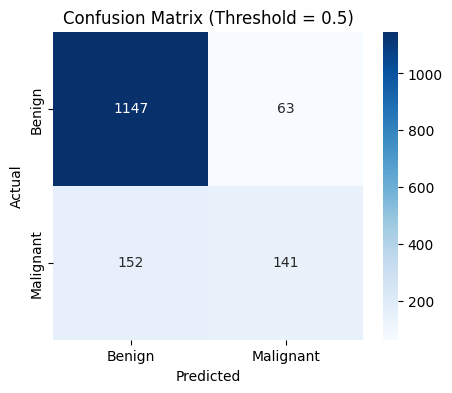

In [17]:
threshold = 0.50
y_pred = (y_probs > threshold).astype(int)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Accuracy:", round(acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)
plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


========== Threshold = 0.5 ==========
Accuracy: 0.857
              precision    recall  f1-score   support

      Benign       0.88      0.95      0.91      1210
   Malignant       0.69      0.48      0.57       293

    accuracy                           0.86      1503
   macro avg       0.79      0.71      0.74      1503
weighted avg       0.85      0.86      0.85      1503



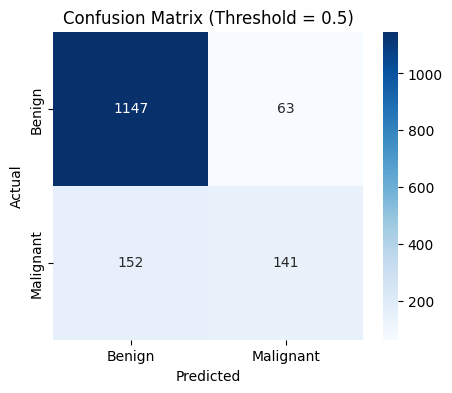


========== Threshold = 0.45 ==========
Accuracy: 0.845
              precision    recall  f1-score   support

      Benign       0.92      0.89      0.90      1210
   Malignant       0.59      0.66      0.62       293

    accuracy                           0.84      1503
   macro avg       0.75      0.78      0.76      1503
weighted avg       0.85      0.84      0.85      1503



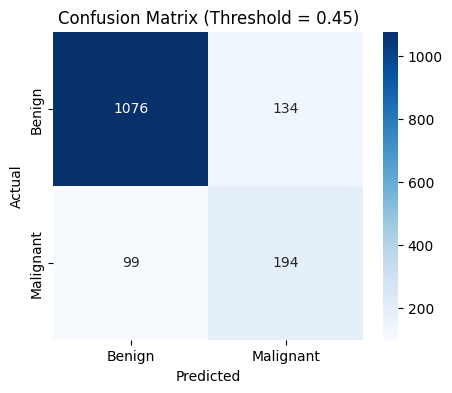


========== Threshold = 0.4 ==========
Accuracy: 0.7964
              precision    recall  f1-score   support

      Benign       0.95      0.79      0.86      1210
   Malignant       0.49      0.82      0.61       293

    accuracy                           0.80      1503
   macro avg       0.72      0.81      0.74      1503
weighted avg       0.86      0.80      0.81      1503



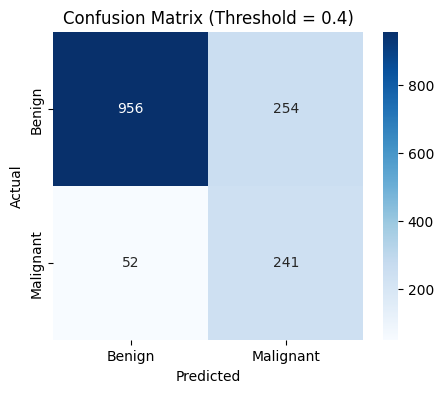


========== Threshold = 0.35 ==========
Accuracy: 0.7385
              precision    recall  f1-score   support

      Benign       0.97      0.70      0.81      1210
   Malignant       0.42      0.92      0.58       293

    accuracy                           0.74      1503
   macro avg       0.70      0.81      0.69      1503
weighted avg       0.86      0.74      0.77      1503



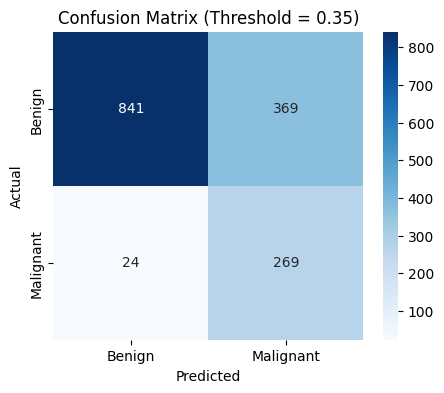


========== Threshold = 0.3 ==========
Accuracy: 0.6653
              precision    recall  f1-score   support

      Benign       0.99      0.59      0.74      1210
   Malignant       0.37      0.98      0.53       293

    accuracy                           0.67      1503
   macro avg       0.68      0.78      0.64      1503
weighted avg       0.87      0.67      0.70      1503



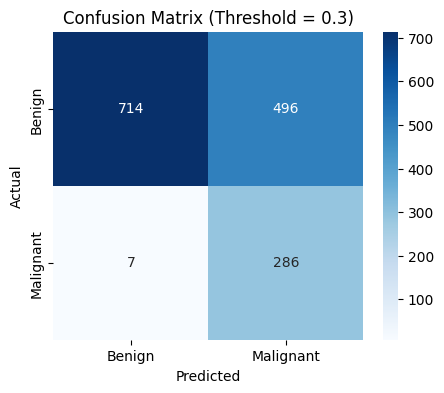

In [18]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30]

for threshold in thresholds:
    y_pred = (y_probs > threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n========== Threshold = {threshold} ==========")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"]
    )
    plt.title(f"Confusion Matrix (Threshold = {threshold})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()